In [1]:
import numpy as np 
import pandas as pd 
import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="bbrsCDbFqgCpWkPYiqdt")
project = rf.workspace("hagers-workspace-gsta3").project("minecraft_capstone-7lvby")
version = project.version(1)
dataset = version.download("yolo26")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 3.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.6 MB/s eta 0:00:00:00:010:01
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Minecraft_Capstone-1 in yolo26:: 100%|██████████| 1911/1911 [00:00<00:00, 10255.05it/s]


In [3]:
# Install ultralytics (YOLOv8)
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.9 MB/s eta 0:00:00


In [4]:
# Import YOLO
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [5]:
model.train(
    data="/kaggle/working/Minecraft_Capstone-1/data.yaml", 
    epochs=50, 
    imgsz=512,    
    batch=16,    
    # device=0     
)

Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Minecraft_Capstone-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, n

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


       2/50      1.85G     0.8752      4.034   0.007749          2        512: 100% ━━━━━━━━━━━━ 53/53 7.1it/s 7.5s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 8.3it/s 0.2s0.4s
                   all         60         67      0.834      0.417      0.742      0.612

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       3/50      1.85G     0.9043      3.266      0.008          7        512: 100% ━━━━━━━━━━━━ 53/53 7.2it/s 7.4s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 8.0it/s 0.2s0.4s
                   all         60         67      0.598      0.809      0.771      0.676

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       4/50      1.85G     0.8584      2.716   0.007393          2        512: 100% ━━━━━━━━━━━━ 53/53 7.3it/s 7.2s0.1s
                 Class     Images  Instances  

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b848236bb30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [6]:
model.val()

Ultralytics 8.4.138 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,376,006 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1290.6±271.8 MB/s, size: 35.3 KB)
val: Scanning /kaggle/working/Minecraft_Capstone-1/valid/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 22.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.1it/s 1.3s0.5s
                   all         60         67      0.922      0.917      0.942       0.86
                   cow          9         10          1      0.879      0.935      0.876
               creeper         11         11          1      0.948      0.995      0.913
                 house          5          8      0.588       0.75      0.735      0.639
                   pig         14         14      0.979          1      0.995       0.99
              villager    

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b85e4851b50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     


image 1/1 /kaggle/working/Minecraft_Capstone-1/test/images/Screenshot-14-_png.rf.c0848a2d5513d29be40a79b9a37d400e.jpg: 512x512 5 houses, 12.2ms
Speed: 1.3ms preprocess, 12.2ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 512)


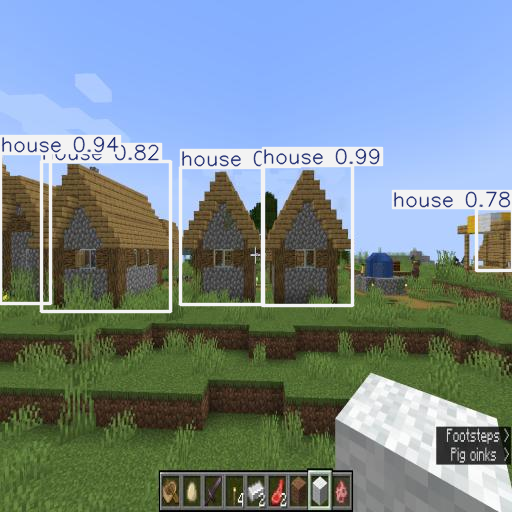

In [8]:
test_1 = model("/kaggle/working/Minecraft_Capstone-1/test/images/Screenshot-14-_png.rf.c0848a2d5513d29be40a79b9a37d400e.jpg")
test_1[0].show()


image 1/1 /kaggle/working/Minecraft_Capstone-1/test/images/creeper00008_png.rf.d61d5220ab920db1da7f2f06c2d7bda9.jpg: 512x512 1 creeper, 12.9ms
Speed: 1.1ms preprocess, 12.9ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 512)


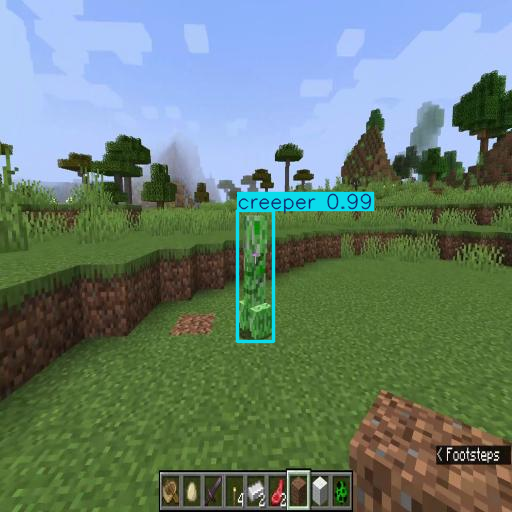

In [9]:
test_2 = model("/kaggle/working/Minecraft_Capstone-1/test/images/creeper00008_png.rf.d61d5220ab920db1da7f2f06c2d7bda9.jpg")
test_2[0].show()


image 1/1 /kaggle/working/Minecraft_Capstone-1/test/images/pig00011_png.rf.d1bb29aa51851521b0d7567fbfd48c28.jpg: 512x512 1 pig, 12.2ms
Speed: 1.2ms preprocess, 12.2ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 512)


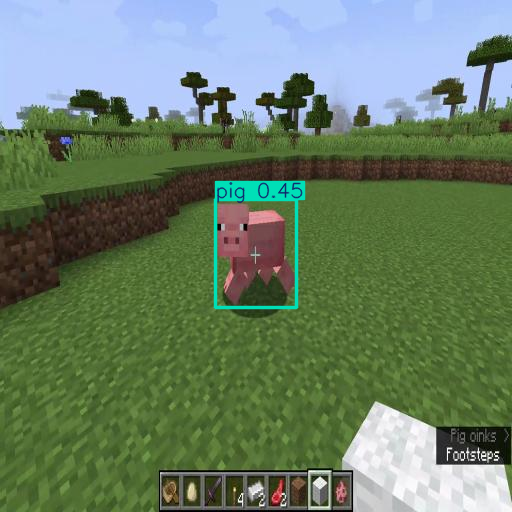

In [10]:
test_3 = model("/kaggle/working/Minecraft_Capstone-1/test/images/pig00011_png.rf.d1bb29aa51851521b0d7567fbfd48c28.jpg")
test_3[0].show()


image 1/1 /kaggle/working/Minecraft_Capstone-1/test/images/tree-extracted00008_png.rf.74f46c714f23bfca7d7e9594d94b38f3.jpg: 512x512 1 cow, 12.6ms
Speed: 1.2ms preprocess, 12.6ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 512)


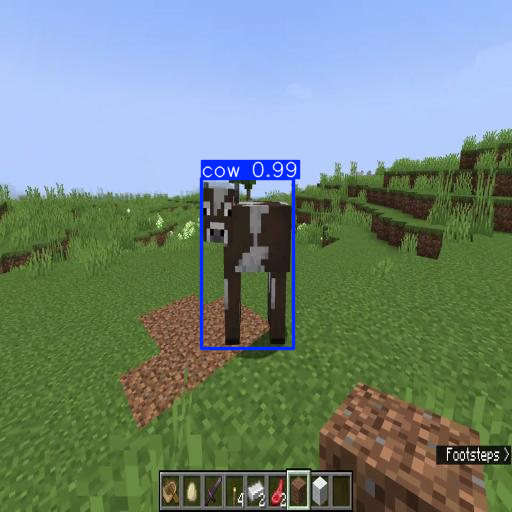

In [11]:
test_4 = model("/kaggle/working/Minecraft_Capstone-1/test/images/tree-extracted00008_png.rf.74f46c714f23bfca7d7e9594d94b38f3.jpg")
test_4[0].show()


image 1/1 /kaggle/working/Minecraft_Capstone-1/test/images/villager00005-Copy_png.rf.d4c57afe9a79e5b01470a76d731d93e9.jpg: 512x512 1 villager, 12.0ms
Speed: 0.9ms preprocess, 12.0ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 512)


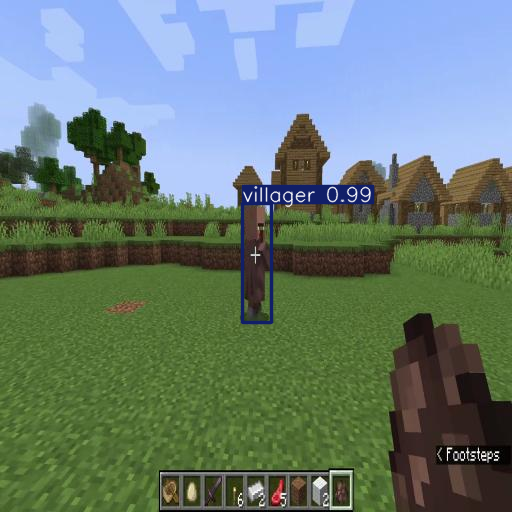

In [12]:
test_5 = model("/kaggle/working/Minecraft_Capstone-1/test/images/villager00005-Copy_png.rf.d4c57afe9a79e5b01470a76d731d93e9.jpg")
test_5[0].show()


image 1/1 /kaggle/working/Minecraft_Capstone-1/test/images/white_sheep00009_png.rf.9e17772b2a7957d46f18113f10d90e37.jpg: 512x512 1 white_sheep, 11.5ms
Speed: 1.0ms preprocess, 11.5ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 512)


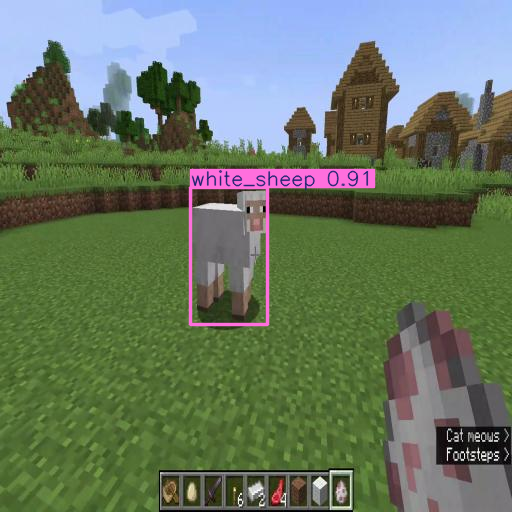

In [13]:
test_6 = model("/kaggle/working/Minecraft_Capstone-1/test/images/white_sheep00009_png.rf.9e17772b2a7957d46f18113f10d90e37.jpg")
test_6[0].show()